### 히트맵(Heatmap)

숫자 데이터를 표(격자) 형태로 배치하고, **값의 크기를 색깔로** 나타낸 그래프.
숫자를 하나하나 읽지 않아도 "색이 진한 곳 = 값이 크다"를 한눈에 파악할 수 있다.

**핵심 아이디어**
- 행(row)과 열(column)의 교차점마다 값이 있고, 그 값의 크기에 따라 색이 달라짐
- 색이 진하거나 밝을수록 값이 크고, 반대로 연하거나 어두울수록 값이 작음 (사용하는 색상표에 따라 방향은 다를 수 있음)

**주로 쓰이는 경우**

| 용도 | 예시 |
|---|---|
| 상관관계 파악 | 여러 변수 간 관계를 표 하나로 확인 |
| 시간 x 항목 패턴 | 요일별 x 카테고리별 주문 건수 |
| 지리적 분포 | 지역별 x 상품별 평균 가격 |
| 대용량 데이터 탐색 | 수천 개 변수를 한눈에 훑어보기 |

> 히트맵은 "정확한 숫자"보다 "**상대적으로 어디가 크고 작은지**"를 빠르게 파악하는 데 특화된 시각화 방법이다.

In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


df.head()

C:\Users\soldesk\AppData\Local\Temp\ipykernel_7956\2036139076.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

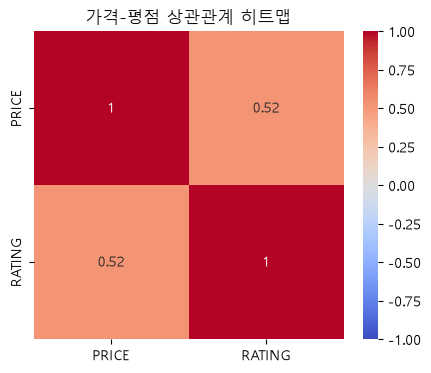

In [3]:
import seaborn as sns

numeric_df = df[["PRICE", "RATING"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("가격-평점 상관관계 히트맵")
plt.show()